In [1]:
'''
Import libraries
'''
import numpy as np
from scipy.sparse import linalg

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

In [ ]:
'''
Initializations
'''
# Create a list of 40 bond lengths for the Hydrogen molecule
bond_lengths = np.linspace(0.2, 3.5, num=40)

# 1 is ground state energy level, and 2 is excited state energy level
energy_levels = 2

# Create an empty array to store the ground and excited states
# energies simulated at different bond lengths
energy = []

In [3]:
'''
Simulate the ground state energy of the Hydrogen molecule at each bond length
'''
for bond_length in bond_lengths:

    # Set molecule parameters
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, bond_length))]
    basis = 'sto-3g'
    multiplicity = 1
    charge = 0

    # Perform electronic structure calculations and
    # obtain Hamiltonian as an InteractionOperator
    hamiltonian = ofpyscf.generate_molecular_hamiltonian(
            geometry, basis, multiplicity, charge)

    # Convert to a FermionOperator
    hamiltonian_ferm_op = of.get_fermion_operator(hamiltonian)

    # Map to QubitOperator using the BKT
    hamiltonian_bk = of.bravyi_kitaev(hamiltonian_ferm_op)

    # Convert to Scipy sparse matrix
    hamiltonian_bk_sparse = of.get_sparse_operator(hamiltonian_bk)

    # Compute ground and excited state energies
    eigs, _ = linalg.eigsh(hamiltonian_bk_sparse, k= energy_levels, which='SA')
    ground_excited_energies = eigs #[1] #[0]

    # Store the ground and excited state energies at each bond length in the energy array
    if bond_length == bond_lengths[0]:
        energy = np.array(ground_excited_energies)
    else:
        energy = np.vstack([energy, ground_excited_energies])

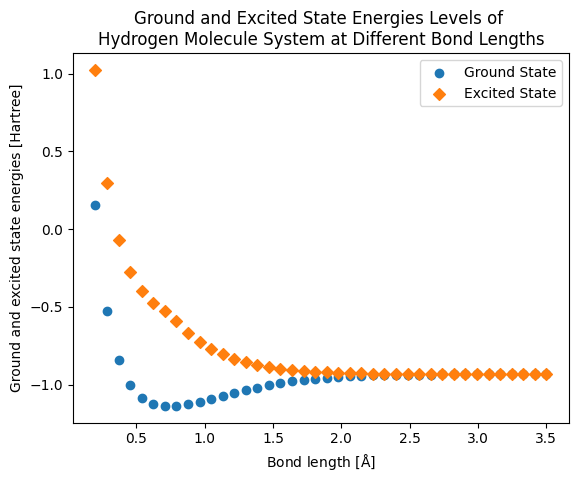

In [4]:
'''
Generate the plot of ground state energy of the Hydrogen molecule
as the function of the 40 bond lengths
'''
markers = ["o", "D"]
for i in range(energy_levels):
    plt.scatter(bond_lengths, energy[:,i:i+1], marker = markers[i])

# Add labels, title and legend on the plot
plt.xlabel('Bond length [$\mathrm{\AA}$]')
plt.ylabel('Ground and excited state energies [Hartree]')
plt.title('Ground and Excited State Energies Levels of \n'
          'Hydrogen Molecule System at Different Bond Lengths')
plt.legend(["Ground State", "Excited State"])

# Save an show the plot
plt.savefig('groundExcitedEnergy.png')
plt.show()